In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.io import loadmat
from sklearn.preprocessing import OneHotEncoder

In [2]:
data = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex4data1.mat")
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Oct 16 13:09:09 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(5000, 400)),
 'y': array([[10],
        [10],
        [10],
        ...,
        [ 9],
        [ 9],
        [ 9]], shape=(5000, 1), dtype=uint8)}

In [3]:
X=data['X']
y = data['y']

X.shape,y.shape

((5000, 400), (5000, 1))

In [5]:
weight = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex4weights.mat")
theta1,theta2 = weight['Theta1'],weight['Theta2']
theta1.shape,theta2.shape

((25, 401), (10, 26))

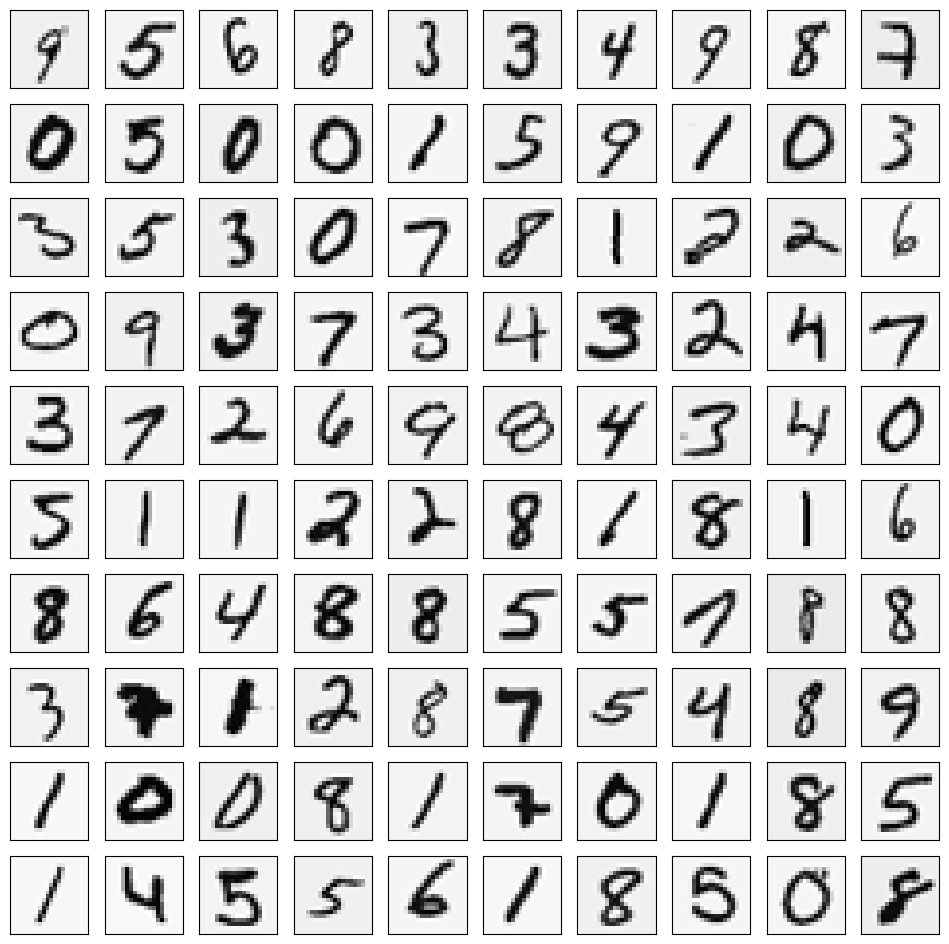

In [8]:
sample_idx = np.random.choice(np.arange(data['X'].shape[0]),100)
sample_images = data['X'][sample_idx,:]
fig,ax_array = plt.subplots(nrows=10,ncols=10,sharey=True,sharex=True,figsize=(12,12))
for r in range(10):
    for c in range(10):
        ax_array[r,c].matshow(np.array(sample_images[10*r + c].reshape((20,20))).T,cmap=matplotlib.cm.binary)
        plt.xticks(np.array([]))
        plt.yticks(np.array([]))

In [9]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [12]:
def forward_propagate(X,theta1,theta2):
    m = X.shape[0]

    a1 = np.insert(X,0,values=np.ones(m),axis=1)
    z2 = a1 * theta1.T
    a2 = np.insert(sigmoid(z2),0,values=np.ones(m),axis=1)
    z3 = a2 *theta2.T
    h = sigmoid(z3)

    return a1,z2,a2,z3,h

In [14]:
def cost(theta1,theta2,input_size,hidden_size,num_labels,X,y,learning_rate):
    m = X.shape[0]
    X = np.matrix(X)
    y = np.matrix(y)

    a1,z2,a2,z3,h=forward_propagate(X,theta1,theta2)

    J=0
    for i in range(m):
        first_term = np.multiply(-y[i,:],np.log(h[i,:]))
        second_term = np.multiply((1-y[i,:]),np.log(1-h[i,:]))
        J+=np.sum(first_term-second_term)

    J=J/m
    return J

In [16]:
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)
y_onehot.shape

(5000, 10)

In [17]:
y[0],y_onehot[0,:]

(array([10], dtype=uint8), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))

In [22]:
input_size = 400
hidden_size =25
num_labels = 10
learning_rate=1

In [23]:
cost(theta1,theta2,input_size,hidden_size,num_labels,X,y_onehot,learning_rate)

np.float64(0.28762916516131876)

In [24]:
def costReg(theta1,theta2,input_size,hidden_size,num_labels,X,y,learning_rate):
    m = X.shape[0]
    X=np.matrix(X)
    y=np.matrix(y)

    a1,z2,a2,z3,h = forward_propagate(X,theta1,theta2)

    J=0
    for i in range(m):
        first_term = np.multiply(-y[i,:],np.log(h[i,:]))
        second_term = np.multiply((1-y[i,:]),np.log(1-h[i,:]))
        J+=np.sum(first_term-second_term)

    J/=m

    J+=(float(learning_rate)/(2*m))*(np.sum(np.power(theta1[:,1:],2))+np.sum(np.power(theta2[:,1:],2)))

    return J

In [25]:
costReg(theta1,theta2,input_size,hidden_size,num_labels,X,y_onehot,learning_rate)

np.float64(0.3837698590909235)

In [26]:
def sigmoid_gradient(z):
    return np.multiply(sigmoid(z),(1-sigmoid(z)))

In [27]:
sigmoid_gradient(0)

np.float64(0.25)

In [51]:
params=(np.random.random(size=hidden_size*(input_size+1)+num_labels*(hidden_size+1))  -0.5)  *0.24

In [59]:
def backprop(params,input_size,hidden_size,num_labels,X,y,learning_rate):
    m = X.shape[0]
    X = np.matrix(X)
    y = np.matrix(y)

    theta1 = np.matrix(np.reshape(params[:hidden_size*(input_size+1)],(hidden_size,(input_size+1))))
    theta2 = np.matrix(np.reshape(params[hidden_size*(input_size+1):],(num_labels,(hidden_size+1))))
    a1,z2,a2,z3,h=forward_propagate(X,theta1,theta2)



    J=0
    delta1= np.zeros(theta1.shape)
    delta2=np.zeros(theta2.shape)

    for i in range(m):
        first_term = np.multiply(-y[i,:],np.log(h[i,:]))
        second_term = np.multiply((1-y[i,:]),np.log(1-h[i,:]))
        J += np.sum(first_term - second_term)

    J =J/m

    for t in range(m):
        a1t = a1[t,:]
        z2t = z2[t,:]
        a2t = a2[t,:]
        ht = h[t,:]
        yt = y[t,:]

        d3t = ht -yt

        z2t = np.insert(z2t,0,values=np.ones(1))
        d2t = np.multiply((theta2.T*d3t.T).T,sigmoid_gradient(z2t))

        delta1 +=(d2t[:,1:]).T*a1t
        delta2 +=d3t.T*a2t

    delta1/=m
    delta2/=m

    return J,delta1,delta2

In [60]:
def backpropReg(params,input_size,hidden_size,num_labels,X,y,learning_rate):
    m=X.shape[0]
    X=np.matrix(X)
    y=np.matrix(y)

    theta1 = np.matrix(np.reshape(params[:hidden_size*(input_size+1)],(hidden_size,(input_size+1))))
    theta2 = np.matrix(np.reshape(params[hidden_size*(input_size+1):],(num_labels,(hidden_size+1))))

    a1,z2,a2,z3,h=forward_propagate(X,theta1,theta2)

    J=0
    delta1=np.zeros(theta1.shape)
    delta2=np.zeros(theta2.shape)

    for i in range(m):
        first_term = np.multiply(-y[i,:],np.log(h[i,:]))
        second_term = np.multiply((1-y[i,:]),np.log(1-h[i,:]))
        J+=np.sum(first_term-second_term)

    J/=m

    J+=(float(learning_rate)/(2*m))*(np.sum(np.power(theta1[:,1:],2))+np.sum(np.power(theta2[:,1:],2)))

    for t in range(m):
        alt =a1[t,:]
        z2t = z2[t,:]
        a2t = a2[t,:]
        ht = h[t,:]
        yt = y[t,:]

        d3t = ht -yt

        z2t = np.insert(z2t,0,values=np.ones(1))
        d2t = np.multiply((theta2.T*d3t.T).T,sigmoid_gradient(z2t))

        delta1+=(d2t[:,1:]).T*alt
        delta2+=d3t.T*a2t

    delta1/=m
    delta2/=m

    delta1[:,1:]+=(theta1[:,1:]*learning_rate)/m
    delta2[:,1:]+=(theta2[:,1:]*learning_rate)/m

    grad = np.concatenate((np.ravel(delta1),np.ravel(delta2)))

    return J,grad

In [66]:
J, grad = backpropReg(params, input_size, hidden_size, num_labels, X, y_onehot, learning_rate)
J, grad.shape

(np.float64(6.879743336527507), (10285,))